In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./Input/input.csv")

In [3]:
df = df.sample(n=1000, random_state=42, replace=False)

In [4]:
def plot_histogram(word_counts):
    plt.figure(figsize=(12,6))
    plt.hist(word_counts, bins = 100)
    plt.title("Word Counts of Reviews")
    plt.xlabel("No. of words")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


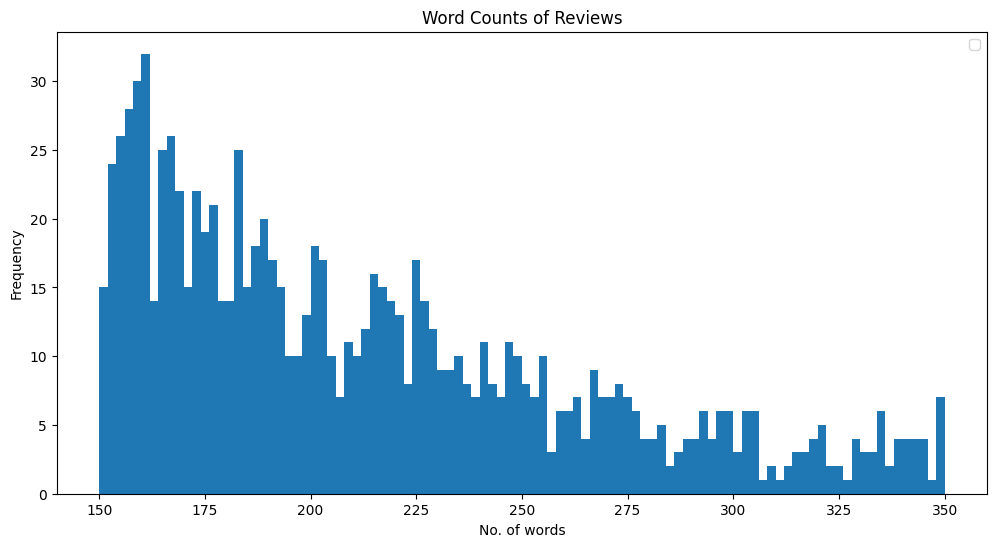

In [5]:
plot_histogram(df["Words"].tolist())

In [6]:
from datasets import Dataset
dataset = Dataset.from_pandas(df)

In [ ]:
sample_text = dataset["Review"][0]
print(sample_text)

In [ ]:
from transformers import pipeline, set_seed
set_seed(42)
pipe =  pipeline(
    "summarization",
    model="google/pegasus-cnn_dailymail",
    device = 0
)
pipe_out = pipe(sample_text)
print(pipe_out[0]["summary_text"].replace(" .<n>", "."))

In [ ]:
pipe =  pipeline(
    "summarization",
    model="t5-large",
    device = 0
)
pipe_out = pipe(sample_text)
print(pipe_out[0]["summary_text"])

In [ ]:
pipe =  pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    device = 0
)
pipe_out = pipe(sample_text)
print(pipe_out[0]["summary_text"])

In [7]:
from tqdm import tqdm
import torch

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
device

'cuda'

In [10]:
def chunks(list_of_elements, batch_size):
    """Yield successive batch-sized chunks from list_of_elements."""
    for i in range(0, len(list_of_elements), batch_size):
        yield list_of_elements[i : i + batch_size]

In [11]:
def summaries_pegasus(dataset,model,tokenizer,batch_size = 16,device = device,column_text = "Review"):
    review_batches = list(chunks(dataset[column_text], batch_size))
    s = []
    for review_batch in tqdm(review_batches, total = len(review_batches)):
        inputs = tokenizer(review_batch, max_length=1024,  truncation=True, 
                        padding="max_length", return_tensors="pt")
        summaries = model.generate(input_ids=inputs["input_ids"].to(device),
                         attention_mask=inputs["attention_mask"].to(device), 
                         length_penalty=0.8, num_beams=8, max_length=128)
        decoded_summaries = [tokenizer.decode(s, skip_special_tokens=True, 
                                clean_up_tokenization_spaces=True) 
               for s in summaries]
        decoded_summaries = [d.replace("<n>", " ") for d in decoded_summaries]
        s.append(decoded_summaries)
    return s

In [15]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_ckpt = "google/pegasus-cnn_dailymail"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)

/home/taufiq/anaconda3/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-cnn_dailymail and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [16]:
s_pegasus = summaries_pegasus(dataset, model, tokenizer, batch_size=1)

100%|███████████████████████████████████████████| 1000/1000 [22:47<00:00,  1.37s/it]


In [15]:
def get_flat_list(nested_list):
    flat_list = [item for sublist in nested_list for item in sublist]
    return flat_list

In [22]:
flat_pegasus = get_flat_list(s_pegasus)

In [23]:
flat_pegasus

["Connecting using the Alexa app is fairly simple, but it just refuses to be a reliable home theater system. It constantly drops sound, or has intermittent sound loss. Happens randomly. Sometimes I'll just turn on the TV and only the sub will be working. If you're looking for a better sound quality home theater than a priced sound barsub combo will probably beat whatever studiosub combo (dollar to dollar)",
 'The camera would constantly deactivate and disconnect from wifi. It is actually supposed to tell me when it’s offline, which it didn’t. But no way of resetting it without being physically there and more than likely to reset the wifi too. I missed the cutoff to return this last one, probably because I’m tired of dealing with crap electronics.',
 'I was excited to receive this but after listening to music on it for an hour, I\'m returning it. My echo studio sounds muted and even like a blown speaker with the way certain highs become twiny. Some songs sound ok but others are just pla

In [25]:
df["S_pegasus"] = flat_pegasus

In [26]:
df.to_csv("./out.csv", index=False)

In [11]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_ckpt = "facebook/bart-large-cnn"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)

/home/taufiq/anaconda3/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [15]:
def summaries_bart(dataset,model,tokenizer,batch_size = 16,device = device,column_text = "Review"):
    review_batches = list(chunks(dataset[column_text], batch_size))
    s = []
    for review_batch in tqdm(review_batches, total = len(review_batches)):
        inputs = tokenizer(review_batch, max_length=1024,  truncation=True, 
                        padding="max_length", return_tensors="pt")
        summaries = model.generate(input_ids=inputs["input_ids"].to(device),
                         attention_mask=inputs["attention_mask"].to(device), 
                         length_penalty=0.8, num_beams=8, max_length=128)
        decoded_summaries = [tokenizer.decode(s, skip_special_tokens=True, 
                                clean_up_tokenization_spaces=True) 
               for s in summaries]
        s.append(decoded_summaries)
    return s

In [16]:
s_bart = summaries_bart(dataset, model, tokenizer, batch_size=1)

100%|███████████████████████████████████████████| 1000/1000 [22:04<00:00,  1.32s/it]


In [18]:
flat_bart = get_flat_list(s_bart)

In [20]:
df = pd.read_csv("./out.csv")

In [23]:
df["S_bart"] = flat_bart

In [24]:
df.to_csv("./out.csv", index=False)

In [25]:
df

,ID,Review,Words,S_pegasus,S_bart
0,29725,So I've been a pretty big fan of Amazon stuff ...,338,Connecting using the Alexa app is fairly simpl...,"As an Alexa device, it's fine. Plays music, do..."
1,67428,This was the third blink I attempted. In the t...,233,The camera would constantly deactivate and dis...,"Buy this if you want to constantly tend to it,..."
2,32991,I was excited to receive this but after listen...,165,I was excited to receive this but after listen...,I was excited to receive this but after listen...
3,43283,I bought this as a Christmas present for the W...,177,We have a great 5.1 stereo downstairs but this...,I bought this as a Christmas present for the W...
4,67236,I purchased 6 of these cameras in December 202...,204,I purchased 6 of these cameras in December 202...,I purchased 6 of these cameras in December 202...
...,...,...,...,...,...
995,35230,CONS:Unless you want to pay another FEE to lis...,167,It plays local radio stations for free. It wil...,Unless you want to pay another FEE to listen t...
996,13119,"I bought it at June 5 2022, in one and half mo...",160,"I bought it at June 5 2022, in one and half mo...","I bought it at June 5 2022, in one and half mo..."
997,2675,I got my Fitbit Charge 5 about Six months ago....,175,I initially bought it to replace my Apple Watc...,The interface is clunky and hard to manage. It...
998,59491,"The blink cameras, with the exception of the d...",168,When Amazon offered replacing them with blink ...,"The blink cameras, with the exception of the d..."


In [12]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_ckpt = "t5-large"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)

/home/taufiq/anaconda3/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [13]:
def summaries_t5(dataset,model,tokenizer,batch_size = 16,device = device,column_text = "Review"):
    review_batches = list(chunks(dataset[column_text], batch_size))
    s = []
    for review_batch in tqdm(review_batches, total = len(review_batches)):
        inputs = tokenizer(review_batch, max_length=1024,  truncation=True, 
                        padding="max_length", return_tensors="pt")
        summaries = model.generate(input_ids=inputs["input_ids"].to(device),
                         attention_mask=inputs["attention_mask"].to(device), 
                         length_penalty=0.8, num_beams=8, max_length=128)
        decoded_summaries = [tokenizer.decode(s, skip_special_tokens=True, 
                                clean_up_tokenization_spaces=True) 
               for s in summaries]
        s.append(decoded_summaries)
    return s

In [14]:
s_t5 = summaries_t5(dataset, model, tokenizer, batch_size=1)

100%|███████████████████████████████████████████| 1000/1000 [52:46<00:00,  3.17s/it]


In [16]:
flat_t5 = get_flat_list(s_t5)

["then you'll be fine. But if you're looking for a home theater upgrade then hold off for at least another 6-12 months..It's a big disappointment so far. It's not worth the money.It's not worth the money.It's not worth the money.Not worth it.Not worth it.Not worth it.Not worth it.Not worth it.Not worth it.Not worth it.Not worth it.Not worth it.",
 'I was so frustrated I waited until the last minute to return this camera.Buy this if you want a better quality camera that actually worksBuy this if you want a better quality camera that actually works. This was the third blink I attempted to make it work.. failed. failed. Picture quality... picture quality.... would.. the.  ',
 ". I was excited to receive this but after listening to the music on it, I'm returning it.I was excited to receive this but after listening to the music on it, I'm returning it.I was excited to receive this but after listening to it for an hour, I'm returning it.I was excited to receive this but after listening to it

In [18]:
df = pd.read_csv("./out.csv")

In [19]:
df

,ID,Review,Words,S_pegasus,S_bart
0,29725,So I've been a pretty big fan of Amazon stuff ...,338,Connecting using the Alexa app is fairly simpl...,"As an Alexa device, it's fine. Plays music, do..."
1,67428,This was the third blink I attempted. In the t...,233,The camera would constantly deactivate and dis...,"Buy this if you want to constantly tend to it,..."
2,32991,I was excited to receive this but after listen...,165,I was excited to receive this but after listen...,I was excited to receive this but after listen...
3,43283,I bought this as a Christmas present for the W...,177,We have a great 5.1 stereo downstairs but this...,I bought this as a Christmas present for the W...
4,67236,I purchased 6 of these cameras in December 202...,204,I purchased 6 of these cameras in December 202...,I purchased 6 of these cameras in December 202...
...,...,...,...,...,...
995,35230,CONS:Unless you want to pay another FEE to lis...,167,It plays local radio stations for free. It wil...,Unless you want to pay another FEE to listen t...
996,13119,"I bought it at June 5 2022, in one and half mo...",160,"I bought it at June 5 2022, in one and half mo...","I bought it at June 5 2022, in one and half mo..."
997,2675,I got my Fitbit Charge 5 about Six months ago....,175,I initially bought it to replace my Apple Watc...,The interface is clunky and hard to manage. It...
998,59491,"The blink cameras, with the exception of the d...",168,When Amazon offered replacing them with blink ...,"The blink cameras, with the exception of the d..."


In [20]:
df["S_t5"] = flat_t5

In [21]:
df

,ID,Review,Words,S_pegasus,S_bart,S_t5
0,29725,So I've been a pretty big fan of Amazon stuff ...,338,Connecting using the Alexa app is fairly simpl...,"As an Alexa device, it's fine. Plays music, do...",then you'll be fine. But if you're looking for...
1,67428,This was the third blink I attempted. In the t...,233,The camera would constantly deactivate and dis...,"Buy this if you want to constantly tend to it,...",I was so frustrated I waited until the last mi...
2,32991,I was excited to receive this but after listen...,165,I was excited to receive this but after listen...,I was excited to receive this but after listen...,. I was excited to receive this but after list...
3,43283,I bought this as a Christmas present for the W...,177,We have a great 5.1 stereo downstairs but this...,I bought this as a Christmas present for the W...,. We are very happy with this product and woul...
4,67236,I purchased 6 of these cameras in December 202...,204,I purchased 6 of these cameras in December 202...,I purchased 6 of these cameras in December 202...,and the company Blink for sub standard product...
...,...,...,...,...,...,...
995,35230,CONS:Unless you want to pay another FEE to lis...,167,It plays local radio stations for free. It wil...,Unless you want to pay another FEE to listen t...,"either don't hear it, or you blow your eardrum..."
996,13119,"I bought it at June 5 2022, in one and half mo...",160,"I bought it at June 5 2022, in one and half mo...","I bought it at June 5 2022, in one and half mo...","from Amazon. I bought it at June 5 2022, in on..."
997,2675,I got my Fitbit Charge 5 about Six months ago....,175,I initially bought it to replace my Apple Watc...,The interface is clunky and hard to manage. It...,. You’d be better off just using an app on you...
998,59491,"The blink cameras, with the exception of the d...",168,When Amazon offered replacing them with blink ...,"The blink cameras, with the exception of the d...",.! Amazon should be ashamed of this product!! ...


In [22]:
df.to_csv("./out.csv", index=False)

In [23]:
df

,ID,Review,Words,S_pegasus,S_bart,S_t5
0,29725,So I've been a pretty big fan of Amazon stuff ...,338,Connecting using the Alexa app is fairly simpl...,"As an Alexa device, it's fine. Plays music, do...",then you'll be fine. But if you're looking for...
1,67428,This was the third blink I attempted. In the t...,233,The camera would constantly deactivate and dis...,"Buy this if you want to constantly tend to it,...",I was so frustrated I waited until the last mi...
2,32991,I was excited to receive this but after listen...,165,I was excited to receive this but after listen...,I was excited to receive this but after listen...,. I was excited to receive this but after list...
3,43283,I bought this as a Christmas present for the W...,177,We have a great 5.1 stereo downstairs but this...,I bought this as a Christmas present for the W...,. We are very happy with this product and woul...
4,67236,I purchased 6 of these cameras in December 202...,204,I purchased 6 of these cameras in December 202...,I purchased 6 of these cameras in December 202...,and the company Blink for sub standard product...
...,...,...,...,...,...,...
995,35230,CONS:Unless you want to pay another FEE to lis...,167,It plays local radio stations for free. It wil...,Unless you want to pay another FEE to listen t...,"either don't hear it, or you blow your eardrum..."
996,13119,"I bought it at June 5 2022, in one and half mo...",160,"I bought it at June 5 2022, in one and half mo...","I bought it at June 5 2022, in one and half mo...","from Amazon. I bought it at June 5 2022, in on..."
997,2675,I got my Fitbit Charge 5 about Six months ago....,175,I initially bought it to replace my Apple Watc...,The interface is clunky and hard to manage. It...,. You’d be better off just using an app on you...
998,59491,"The blink cameras, with the exception of the d...",168,When Amazon offered replacing them with blink ...,"The blink cameras, with the exception of the d...",.! Amazon should be ashamed of this product!! ...
